## 1. Setup & Load All Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pyprojroot import here
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)

ROOT = here()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# ---- File paths ----
imd_2010_path       = DATA_DIR / 'imd_2010.xls'
imd_2019_path       = DATA_DIR / 'imd_2019.csv'
census_od_2021_path = DATA_DIR / 'census_od_2021_msoa.csv'
census_od_2011_path = DATA_DIR / 'census_od_2011_oa.csv'  
lookup_path         = DATA_DIR / 'NSPCL_NOV22_UK_LU.csv'
msoa_lookup_path    = DATA_DIR / 'msoa_2011_to_2021_lookup.csv'

In [3]:
# ---- Load IMD ----
imd_2019 = pd.read_csv(imd_2019_path)
imd_2019.columns = imd_2019.columns.str.strip()

imd_2010 = pd.read_excel(imd_2010_path, sheet_name='IMD 2010')
imd_2010.columns = imd_2010.columns.str.strip()

# ---- Load Census O-D 2021 (MSOA level) ----
census_od_2021 = pd.read_csv(census_od_2021_path)

# ---- Column definitions (from census_od_2021 metadata) ----
# Col A = "Area of usual residence"      = DESTINATION
# Col B = "Area of address 1 year ago"   = ORIGIN
# Col C = "Persons"                       = COUNT
OD_2011_ORIGIN_COL = 'origin_oa'
OD_2011_DEST_COL   = 'dest_oa'
OD_2011_COUNT_COL  = 'persons'

# ---- Load Census O-D 2011 (OA level) ----
census_od_2011_raw = pd.read_csv(
    census_od_2011_path,
    header=None,
    names=['dest_oa', 'origin_oa', 'persons'],  # A=dest, B=origin, C=count
    dtype={'dest_oa': str, 'origin_oa': str, 'persons': int}
)

# Log special codes before they drop out
special_mask = census_od_2011_raw['origin_oa'].str.startswith('OD')
print(f'Rows with special origin codes (cross-border etc): '
      f'{special_mask.sum():,} — these will be excluded')

# ---- Load Lookups ----
lookup = pd.read_csv(lookup_path, encoding='ISO-8859-1', low_memory=False)
msoa_11_21 = pd.read_csv(msoa_lookup_path)

# Quick overview
for name, df in [('IMD 2010', imd_2010), ('IMD 2019', imd_2019),
                  ('Census O-D 2021', census_od_2021),
                  ('Census O-D 2011 (OA)', census_od_2011_raw),
                  ('MSOA Lookup', msoa_11_21)]:
    print(f'\n===== {name} =====')
    print(f'Shape: {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    display(df.head(2))

Rows with special origin codes (cross-border etc): 116,320 — these will be excluded

===== IMD 2010 =====
Shape: (32482, 7)
Columns: ['LSOA CODE', 'LA CODE', 'LA NAME', 'GOR CODE', 'GOR NAME', 'IMD SCORE', 'RANK OF IMD SCORE (where 1 is most deprived)']


,LSOA CODE,LA CODE,LA NAME,GOR CODE,GOR NAME,IMD SCORE,RANK OF IMD SCORE (where 1 is most deprived)
0,E01000001,00AA,City of London,H,London,6.161637,28814
1,E01000002,00AA,City of London,H,London,5.585054,29450



===== IMD 2019 =====
Shape: (32844, 57)
Columns: ['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Score', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% 

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620



===== Census O-D 2021 =====
Shape: (1490726, 5)
Columns: ['Migrant MSOA one year ago code', 'Migrant MSOA one year ago label', 'Middle layer Super Output Areas code', 'Middle layer Super Output Areas label', 'Count']


,Migrant MSOA one year ago code,Migrant MSOA one year ago label,Middle layer Super Output Areas code,Middle layer Super Output Areas label,Count
0,-8,Does not apply,E02000001,City of London 001,6237
1,-8,Does not apply,E02000002,Barking and Dagenham 001,7622



===== Census O-D 2011 (OA) =====
Shape: (3709939, 3)
Columns: ['dest_oa', 'origin_oa', 'persons']


,dest_oa,origin_oa,persons
0,E00000001,E00004655,1
1,E00000001,E00010157,1



===== MSOA Lookup =====
Shape: (7201, 9)
Columns: ['MSOA11CD', 'MSOA11NM', 'CHNGIND', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LAD22NMW', 'ObjectId']


,MSOA11CD,MSOA11NM,CHNGIND,MSOA21CD,MSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E02000001,City of London 001,NaN,E02000001,City of London 001,E09000001,City of London,NaN,1
1,E02000002,Barking and Dagenham 001,NaN,E02000002,Barking and Dagenham 001,E09000002,Barking and Dagenham,NaN,2


---
## 2. Geography Harmonisation

Two separate pipelines:

**2021 O-D**: MSOA-level data uses 2021 codes → map to 2011 MSOA codes via the
ONS MSOA 2011-to-2021 lookup. Only unchanged (1:1) MSOAs are kept.

**2011 O-D**: OA-level data uses native 2011 codes → aggregate to 2011 MSOA codes
using the OA-to-MSOA mapping from the postcode lookup. No cross-year harmonisation needed.

In [4]:
# ---- 2a. MSOA 2021 → 2011 mapping (for 2021 O-D data) ----
msoa_11_21.columns = msoa_11_21.columns.str.strip().str.lower()

unchanged = msoa_11_21[msoa_11_21['msoa11cd'] == msoa_11_21['msoa21cd']].copy()
msoa21_to_11 = dict(zip(unchanged['msoa21cd'], unchanged['msoa11cd']))

print(f'Total MSOAs in lookup: {len(msoa_11_21)}')
print(f'Unchanged (usable):    {len(unchanged)}')
print(f'Dropped (split/merged): {len(msoa_11_21) - len(unchanged)}')

Total MSOAs in lookup: 7201
Unchanged (usable):    7080
Dropped (split/merged): 121


In [5]:
# ---- 2b. OA → MSOA mapping (for 2011 O-D data) ----
# Extract unique OA-to-MSOA assignments from the postcode lookup
oa_to_msoa = (
    lookup[['oa11cd', 'msoa11cd']]
    .drop_duplicates()
    .dropna()
)
# Sanity check: each OA should map to exactly one MSOA
oa_dup = oa_to_msoa.groupby('oa11cd')['msoa11cd'].nunique()
assert (oa_dup == 1).all(), f'{(oa_dup > 1).sum()} OAs map to multiple MSOAs!'
oa_to_msoa_dict = dict(zip(oa_to_msoa['oa11cd'], oa_to_msoa['msoa11cd']))

print(f'OA-to-MSOA mappings: {len(oa_to_msoa_dict):,}')

OA-to-MSOA mappings: 232,044


In [6]:
# ---- 2c. Map 2021 O-D to 2011 MSOA codes ----
ORIGIN_COL_2021 = 'Migrant MSOA one year ago code'
DEST_COL_2021   = 'Middle layer Super Output Areas code'

census_od_2021['origin_msoa11'] = census_od_2021[ORIGIN_COL_2021].map(msoa21_to_11)
census_od_2021['dest_msoa11']   = census_od_2021[DEST_COL_2021].map(msoa21_to_11)

n_total = len(census_od_2021)
n_mapped = census_od_2021[['origin_msoa11', 'dest_msoa11']].notna().all(axis=1).sum()
print(f'2021 O-D records: {n_total:,}')
print(f'Both endpoints mapped to 2011 codes: {n_mapped:,} ({n_mapped/n_total*100:.1f}%)')

2021 O-D records: 1,490,726
Both endpoints mapped to 2011 codes: 1,349,030 (90.5%)


In [7]:
# ---- 2d. Aggregate 2011 O-D from OA to MSOA level ----
census_od_2011 = census_od_2011_raw.copy()

# Map OA codes to MSOA codes
census_od_2011['origin_msoa11'] = census_od_2011[OD_2011_ORIGIN_COL].map(oa_to_msoa_dict)
census_od_2011['dest_msoa11']   = census_od_2011[OD_2011_DEST_COL].map(oa_to_msoa_dict)

n_total_11 = len(census_od_2011)
n_mapped_11 = census_od_2011[['origin_msoa11', 'dest_msoa11']].notna().all(axis=1).sum()
print(f'2011 O-D records (OA level): {n_total_11:,}')
print(f'Both endpoints mapped to MSOA: {n_mapped_11:,} ({n_mapped_11/n_total_11*100:.1f}%)')

# Aggregate to MSOA-to-MSOA flows
census_od_2011_msoa = (
    census_od_2011
    .dropna(subset=['origin_msoa11', 'dest_msoa11'])
    .groupby(['origin_msoa11', 'dest_msoa11'])[OD_2011_COUNT_COL]
    .sum()
    .reset_index()
    .rename(columns={OD_2011_COUNT_COL: 'count'})
)

# Remove non-movers (same origin and destination MSOA)
census_od_2011_msoa = census_od_2011_msoa[
    census_od_2011_msoa['origin_msoa11'] != census_od_2011_msoa['dest_msoa11']
].copy()

print(f'Aggregated MSOA-to-MSOA flow records (2011): {len(census_od_2011_msoa):,}')
print(f'Total migrants (2011): {census_od_2011_msoa["count"].sum():,.0f}')

2011 O-D records (OA level): 3,709,939
Both endpoints mapped to MSOA: 3,556,066 (95.9%)
Aggregated MSOA-to-MSOA flow records (2011): 1,374,520
Total migrants (2011): 5,124,913


---
## 3. London Filter & IMD Aggregation to MSOA

In [8]:
london_boroughs = [
    'City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent',
    'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich',
    'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering',
    'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea',
    'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham',
    'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton',
    'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster'
]

london_lookup = (
    lookup[lookup['ladnm'].isin(london_boroughs)]
    [['lsoa11cd', 'msoa11cd', 'ladnm']]
    .drop_duplicates()
)

# Set of London MSOA codes (used for filtering flows)
london_msoas = set(london_lookup['msoa11cd'].unique())

print(f'London LSOAs: {london_lookup["lsoa11cd"].nunique()}')
print(f'London MSOAs: {len(london_msoas)}')
print(f'Boroughs:     {london_lookup["ladnm"].nunique()}')

London LSOAs: 4835
London MSOAs: 983
Boroughs:     33


In [9]:
# Column name shortcuts
IMD_2010_LSOA_COL  = 'LSOA CODE'
IMD_2010_SCORE_COL = 'IMD SCORE'
IMD_2010_RANK_COL  = 'RANK OF IMD SCORE (where 1 is most deprived)'

IMD_2019_LSOA_COL  = 'LSOA code (2011)'
IMD_2019_SCORE_COL = 'Index of Multiple Deprivation (IMD) Score'
IMD_2019_RANK_COL  = 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'

In [10]:
# ---- Normalise ranks to percentiles ----
# CRITICAL: 2010 has 32,482 LSOAs, 2019 has 32,844 LSOAs.
# Raw ranks are NOT comparable across years. Converting to percentiles
# (rank / n) places every LSOA on a 0–1 scale regardless of total count.
# Higher percentile = less deprived (rank 1 = most deprived → low percentile).
n_lsoa_2010 = len(imd_2010)
n_lsoa_2019 = len(imd_2019)
 
imd_2010['IMD_Percentile_2010'] = (
    imd_2010[IMD_2010_RANK_COL] / n_lsoa_2010
)
imd_2019['IMD_Percentile_2019'] = (
    imd_2019[IMD_2019_RANK_COL] / n_lsoa_2019
)
 
print(f"IMD 2010: {n_lsoa_2010:,} LSOAs (England)")
print(f"IMD 2019: {n_lsoa_2019:,} LSOAs (England)")
print(f"Ranks normalised to percentiles (0 = most deprived, 1 = least)")

IMD 2010: 32,482 LSOAs (England)
IMD 2019: 32,844 LSOAs (England)
Ranks normalised to percentiles (0 = most deprived, 1 = least)


In [11]:
# ---- Join to London lookup & aggregate to MSOA ----
 
# IMD 2010 → MSOA (scores + ranks + percentiles)
imd_2010_london = pd.merge(
    imd_2010[[IMD_2010_LSOA_COL, IMD_2010_SCORE_COL,
              IMD_2010_RANK_COL, 'IMD_Percentile_2010']],
    london_lookup,
    left_on=IMD_2010_LSOA_COL, right_on='lsoa11cd'
)
 
msoa_imd_2010 = (
    imd_2010_london
    .groupby(['msoa11cd', 'ladnm'])
    .agg(
        IMD_2010       = (IMD_2010_SCORE_COL, 'mean'),
        IMD_Rank_2010  = (IMD_2010_RANK_COL, 'mean'),
        IMD_Pctile_2010= ('IMD_Percentile_2010', 'mean'),
    )
    .reset_index()
)
 
# IMD 2019 → MSOA (scores + ranks + percentiles)
imd_2019_london = pd.merge(
    imd_2019[[IMD_2019_LSOA_COL, IMD_2019_SCORE_COL,
              IMD_2019_RANK_COL, 'IMD_Percentile_2019']],
    london_lookup,
    left_on=IMD_2019_LSOA_COL, right_on='lsoa11cd'
)
 
msoa_imd_2019 = (
    imd_2019_london
    .groupby('msoa11cd')
    .agg(
        IMD_2019       = (IMD_2019_SCORE_COL, 'mean'),
        IMD_Rank_2019  = (IMD_2019_RANK_COL, 'mean'),
        IMD_Pctile_2019= ('IMD_Percentile_2019', 'mean'),
    )
    .reset_index()
)

In [12]:
# ---- Combine & compute change metrics ----
msoa_wealth = pd.merge(msoa_imd_2010, msoa_imd_2019, on='msoa11cd', how='inner')
 
# PRIMARY METRIC: Percentile change (rank-based, comparable across years)
# Positive = MSOA moved UP in national ranking = became relatively LESS deprived
msoa_wealth['IMD_Pctile_Change'] = (
    msoa_wealth['IMD_Pctile_2019'] - msoa_wealth['IMD_Pctile_2010']
)
 
# SECONDARY METRIC: Raw score change (kept for descriptive context only)
# Negative = lower deprivation score in 2019 = less deprived
# NOT strictly comparable across years — use with caveats
msoa_wealth['IMD_Score_Change'] = (
    msoa_wealth['IMD_2019'] - msoa_wealth['IMD_2010']
)
 
print(f'\nLondon MSOAs with both IMD years: {len(msoa_wealth)}')
print(f'\n--- Percentile Change (PRIMARY) ---')
print(f'  Positive = moved up in national ranking = less deprived')
print(msoa_wealth['IMD_Pctile_Change'].describe().round(4))
print(f'\n--- Score Change (SECONDARY) ---')
print(f'  Negative = lower deprivation score = less deprived')
print(msoa_wealth['IMD_Score_Change'].describe().round(2))


London MSOAs with both IMD years: 983

--- Percentile Change (PRIMARY) ---
  Positive = moved up in national ranking = less deprived
count    983.0000
mean       0.0642
std        0.0663
min       -0.1400
25%        0.0169
50%        0.0587
75%        0.1056
max        0.3951
Name: IMD_Pctile_Change, dtype: float64

--- Score Change (SECONDARY) ---
  Negative = lower deprivation score = less deprived
count    983.00
mean      -3.94
std        4.64
min      -30.53
25%       -6.29
50%       -2.83
75%       -0.59
max        9.40
Name: IMD_Score_Change, dtype: float64


In [14]:
# Summary
n_up = (msoa_wealth['IMD_Pctile_Change'] > 0).sum()
n_down = (msoa_wealth['IMD_Pctile_Change'] < 0).sum()
n_total = len(msoa_wealth)
print(f'Rank-based: {n_up} MSOAs moved UP ({n_up/n_total*100:.1f}%), '
      f'{n_down} moved DOWN ({n_down/n_total*100:.1f}%)')

Rank-based: 829 MSOAs moved UP (84.3%), 154 moved DOWN (15.7%)


---
## 4. Wealth Decile Assignment (Fixed 2010 Baseline)

Deciles are assigned using **IMD 2010 only**. This fixed classification is applied
identically to **both** the 2011 and 2021 O-D data, so any difference in cascade
flows is attributable to changes in migration patterns, not area reclassification.

Convention: 1 = most deprived, 10 = least deprived (wealthiest).

In [16]:
msoa_wealth['Wealth_Decile'] = pd.qcut(
    msoa_wealth['IMD_2010'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile'] = 11 - msoa_wealth['Wealth_Decile']
# 1 = most deprived, 10 = least deprived (wealthiest)
 
wealth_dict = msoa_wealth.set_index('msoa11cd')['Wealth_Decile'].to_dict()
 
# Robustness: IMD 2019 deciles
msoa_wealth['Wealth_Decile_2019'] = pd.qcut(
    msoa_wealth['IMD_2019'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile_2019'] = 11 - msoa_wealth['Wealth_Decile_2019']
 
wealth_dict_2019 = msoa_wealth.set_index('msoa11cd')['Wealth_Decile_2019'].to_dict()
 
decile_counts = msoa_wealth['Wealth_Decile'].value_counts().sort_index()
print(f'\nAverage MSOAs per decile: {decile_counts.mean():.1f}')
print(decile_counts)


Average MSOAs per decile: 98.3
Wealth_Decile
1     99
2     98
3     98
4     98
5     98
6     99
7     98
8     98
9     98
10    99
Name: count, dtype: int64


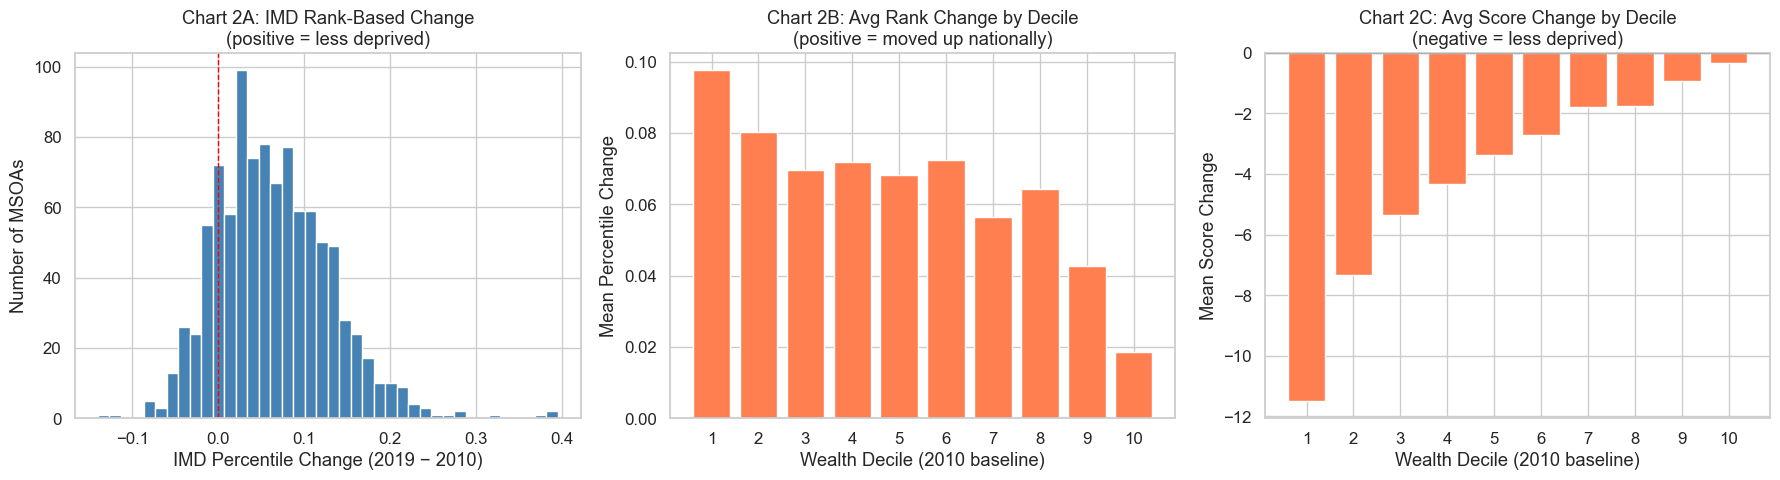

In [ ]:
# =====================================================================
# IMD Change Analysis (updated for rank-based metric)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# A: Percentile change distribution (PRIMARY)
axes[0].hist(msoa_wealth['IMD_Pctile_Change'], bins=40,
             color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('IMD Percentile Change (2019 − 2010)')
axes[0].set_ylabel('Number of MSOAs')
axes[0].set_title('Chart 2A: IMD Rank-Based Change\n(positive = less deprived)')
 
# B: Percentile change by baseline decile
decile_pctile = msoa_wealth.groupby('Wealth_Decile')['IMD_Pctile_Change'].mean()
colors = ['coral' if v > 0 else 'steelblue' for v in decile_pctile.values]
axes[1].bar(decile_pctile.index, decile_pctile.values, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Wealth Decile (2010 baseline)')
axes[1].set_ylabel('Mean Percentile Change')
axes[1].set_title('Chart 2B: Avg Rank Change by Decile\n(positive = moved up nationally)')
axes[1].set_xticks(range(1, 11))
 
# C: Score change by decile (SECONDARY — for comparison)
decile_score = msoa_wealth.groupby('Wealth_Decile')['IMD_Score_Change'].mean()
colors2 = ['coral' if v < 0 else 'steelblue' for v in decile_score.values]
axes[2].bar(decile_score.index, decile_score.values, color=colors2, edgecolor='white')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Wealth Decile (2010 baseline)')
axes[2].set_ylabel('Mean Score Change')
axes[2].set_title('Chart 2C: Avg Score Change by Decile\n(negative = less deprived)')
axes[2].set_xticks(range(1, 11))
 
plt.tight_layout()
save_path = OUTPUT_DIR / 'fig2b_imd_change_rank_and_score.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ---- Robustness: IMD 2019 deciles (for later sensitivity check) ----
msoa_wealth['Wealth_Decile_2019'] = pd.qcut(
    msoa_wealth['IMD_2019'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile_2019'] = 11 - msoa_wealth['Wealth_Decile_2019']

wealth_dict_2019 = msoa_wealth.set_index('msoa11cd')['Wealth_Decile_2019'].to_dict()

print('IMD 2019 deciles computed (for robustness check in Part B).')

IMD 2019 deciles computed (for robustness check in Part B).


---
## 5. O-D Flow Processing: Build London Flow Tables for Both Years

A reusable function processes either year's O-D data into:
- London-to-London flow table with decile assignments
- Flow matrix (decile × decile)
- Flow direction summary
- Per-MSOA cascade features

In [19]:
def build_london_flows(od_df, origin_col, dest_col, count_col, wealth_mapping,
                        london_msoa_set, year_label):
    """
    Process O-D data into London-to-London flows with decile assignments.
    
    Parameters
    ----------
    od_df : DataFrame with origin_msoa11, dest_msoa11 already mapped
            (or raw MSOA codes in origin_col/dest_col)
    origin_col, dest_col : column names for origin/dest MSOA 2011 codes
    count_col : column name for migrant count
    wealth_mapping : dict mapping msoa11cd → Wealth_Decile
    london_msoa_set : set of London MSOA codes
    year_label : str, e.g. '2011' or '2021'
    
    Returns
    -------
    london_flow : DataFrame of London-to-London flows with decile info
    flow_matrix : pivot table (origin_decile × dest_decile)
    flow_direction : Series with upward/downward/lateral/total counts
    shift_dist : Series indexed by Decile_Shift
    """
    df = od_df.copy()
    
    # Assign deciles
    df['Origin_Decile'] = df[origin_col].map(wealth_mapping)
    df['Dest_Decile']   = df[dest_col].map(wealth_mapping)
    
    # Keep only London-to-London flows with valid deciles
    london_flow = df.dropna(subset=['Origin_Decile', 'Dest_Decile']).copy()
    london_flow['Origin_Decile'] = london_flow['Origin_Decile'].astype(int)
    london_flow['Dest_Decile']   = london_flow['Dest_Decile'].astype(int)
    london_flow['Decile_Shift']  = london_flow['Dest_Decile'] - london_flow['Origin_Decile']
    
    # Flow matrix
    flow_matrix = london_flow.pivot_table(
        index='Origin_Decile', columns='Dest_Decile',
        values=count_col, aggfunc='sum', fill_value=0
    )
    
    # Direction summary
    total = london_flow[count_col].sum()
    upward   = london_flow[london_flow['Decile_Shift'] > 0][count_col].sum()
    downward = london_flow[london_flow['Decile_Shift'] < 0][count_col].sum()
    lateral  = london_flow[london_flow['Decile_Shift'] == 0][count_col].sum()
    
    flow_direction = pd.Series({
        'Upward': upward, 'Downward': downward,
        'Lateral': lateral, 'Total': total
    })
    
    # Shift distribution
    shift_dist = london_flow.groupby('Decile_Shift')[count_col].sum()
    
    print(f'\n=== {year_label} Flow Summary ===')
    print(f'  London-to-London records: {len(london_flow):,}')
    print(f'  Total migrants:           {total:,.0f}')
    print(f'  Upward:  {upward:>10,.0f} ({upward/total*100:.1f}%)')
    print(f'  Down:    {downward:>10,.0f} ({downward/total*100:.1f}%)')
    print(f'  Lateral: {lateral:>10,.0f} ({lateral/total*100:.1f}%)')
    
    return london_flow, flow_matrix, flow_direction, shift_dist

In [20]:
def compute_base_flows(london_flow, count_col, origin_msoa_col, dest_msoa_col):
    """
    Step 1: Compute per-MSOA base flow counts from the London flow table.
    Returns a DataFrame with core aggregations.
    """
    # Inflow from wealthier areas (Origin Decile > Dest Decile)
    inflow_w = (
        london_flow[london_flow['Origin_Decile'] > london_flow['Dest_Decile']]
        .groupby(dest_msoa_col)[count_col].sum()
        .rename('Inflow_Wealthier')
    )
    
    # Outflow to more deprived areas (Dest Decile < Origin Decile)
    outflow_p = (
        london_flow[london_flow['Dest_Decile'] < london_flow['Origin_Decile']]
        .groupby(origin_msoa_col)[count_col].sum()
        .rename('Outflow_Poorer')
    )
    
    # Total inflow & outflow
    total_in  = london_flow.groupby(dest_msoa_col)[count_col].sum().rename('Total_Inflow')
    total_out = london_flow.groupby(origin_msoa_col)[count_col].sum().rename('Total_Outflow')
    
    # Combine base metrics
    base_flows = pd.DataFrame(index=inflow_w.index.union(outflow_p.index)
                                          .union(total_in.index)
                                          .union(total_out.index))
    base_flows.index.name = 'msoa11cd'
    
    for s in [inflow_w, outflow_p, total_in, total_out]:
        base_flows = base_flows.join(s, how='left')
        
    return base_flows.fillna(0)

In [21]:
def compute_cascade_features(base_flows):
    """
    Step 2: Compute derived cascade metrics (CFI_churn, CFI_rate) 
    from the pre-calculated base flows.
    """
    cascade = base_flows.copy()
    
    # Calculate Total Migration (Turnover Volume) for normalization
    cascade['Total_Migration'] = cascade['Total_Inflow'] + cascade['Total_Outflow']
    
    # --- CFI METRICS ---
    
    # 1. Composite Index: Intensity of the churn
    cascade['CFI_Churn'] = cascade['Inflow_Wealthier'] + cascade['Outflow_Poorer']
    
    # 2. Normalized Interaction Term
    # We use np.where to safely handle areas with 0 total migration to avoid division by zero errors
    cascade['CFI_Rate'] = np.where(
        cascade['Total_Migration'] > 0,
        (cascade['Inflow_Wealthier'] * cascade['Outflow_Poorer']) / cascade['Total_Migration'],
        0  # Default to 0 if there is no migration
    )
    
    # --- RETAINED LEGACY METRICS ---
    cascade['Net_Cascade'] = cascade['Inflow_Wealthier'] - cascade['Outflow_Poorer']
    cascade['Pct_Inflow_Wealthier'] = np.where(
        cascade['Total_Inflow'] > 0,
        (cascade['Inflow_Wealthier'] / cascade['Total_Inflow']) * 100,
        0
    )
    
    return cascade

In [22]:
# ---- 5a. Process 2021 O-D flows ----
od_2021 = census_od_2021.copy()
od_2021 = od_2021[od_2021[ORIGIN_COL_2021].astype(str) != '-8'].copy()

# Detect count column
count_cols_2021 = [c for c in od_2021.columns
                   if 'observation' in c.lower() or 'count' in c.lower()]
COUNT_COL_2021 = count_cols_2021[0] if count_cols_2021 else '_count'
if COUNT_COL_2021 == '_count':
    od_2021[COUNT_COL_2021] = 1

london_flow_2021, flow_matrix_2021, flow_dir_2021, shift_dist_2021 = build_london_flows(
    od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021,
    wealth_dict, london_msoas, '2021'
)

base_flows_2021 = compute_base_flows(
    london_flow=london_flow_2021, 
    count_col=COUNT_COL_2021, 
    origin_msoa_col='origin_msoa11', 
    dest_msoa_col='dest_msoa11'
)

cascade_2021 = compute_cascade_features(base_flows_2021)


=== 2021 Flow Summary ===
  London-to-London records: 174,274
  Total migrants:           766,502
  Upward:     307,759 (40.2%)
  Down:       272,397 (35.5%)
  Lateral:    186,346 (24.3%)


In [23]:
# ---- 5b. Process 2011 O-D flows ----
london_flow_2011, flow_matrix_2011, flow_dir_2011, shift_dist_2011 = build_london_flows(
    census_od_2011_msoa, 'origin_msoa11', 'dest_msoa11', 'count',
    wealth_dict, london_msoas, '2011'
)

base_flows_2011 = compute_base_flows(
    london_flow=london_flow_2011, 
    count_col='count', 
    origin_msoa_col='origin_msoa11', 
    dest_msoa_col='dest_msoa11'
)

cascade_2011 = compute_cascade_features(base_flows_2011)


=== 2011 Flow Summary ===
  London-to-London records: 173,595
  Total migrants:           768,423
  Upward:     327,528 (42.6%)
  Down:       309,434 (40.3%)
  Lateral:    131,461 (17.1%)


In [24]:
# ---- 5c. Robustness: Process 2021 flows using IMD 2019 deciles ----
london_flow_2021_alt, flow_matrix_2021_alt, flow_dir_2021_alt, shift_dist_2021_alt = build_london_flows(
    od_2021, 'origin_msoa11', 'dest_msoa11', COUNT_COL_2021,
    wealth_dict_2019, london_msoas, '2021 (IMD 2019 deciles)'
)

base_flows_2021_alt = compute_base_flows(
    london_flow=london_flow_2021_alt, 
    count_col=COUNT_COL_2021, 
    origin_msoa_col='origin_msoa11', 
    dest_msoa_col='dest_msoa11'
)

cascade_2021_alt = compute_cascade_features(base_flows_2021_alt)


=== 2021 (IMD 2019 deciles) Flow Summary ===
  London-to-London records: 174,274
  Total migrants:           766,502
  Upward:     310,973 (40.6%)
  Down:       279,074 (36.4%)
  Lateral:    176,455 (23.0%)


---
## 6. Combine into Master Analysis Table

Merge 2011 and 2021 cascade features onto the MSOA wealth table.

In [29]:
# ---- Merge cascade features from both years ----
msoa_analysis = msoa_wealth[['msoa11cd', 'ladnm', 'Wealth_Decile',
                              'Wealth_Decile_2019',
                              'IMD_2010', 'IMD_2019',
                              'IMD_Rank_2010', 'IMD_Rank_2019',
                              'IMD_Pctile_2010', 'IMD_Pctile_2019',
                              'IMD_Pctile_Change',   # PRIMARY validation metric
                              'IMD_Score_Change',     # SECONDARY (descriptive)
                              ]].copy()

# Rename cascade columns with year suffixes
c11 = cascade_2011.add_suffix('_11')
c21 = cascade_2021.add_suffix('_21')

# Merge standard features AND the alt Net, Inflow, and Outflow Cascade features
msoa_analysis = (
    msoa_analysis
    .merge(c11, left_on='msoa11cd', right_index=True, how='left')
    .merge(c21, left_on='msoa11cd', right_index=True, how='left')
    .merge(
        cascade_2021_alt[['Net_Cascade', 'Inflow_Wealthier', 'Outflow_Poorer']].rename(
            columns={
                'Net_Cascade': 'Net_Cascade_21_alt',
                'Inflow_Wealthier': 'Inflow_Wealthier_21_alt',
                'Outflow_Poorer': 'Outflow_Poorer_21_alt'
            }
        ),
        left_on='msoa11cd', right_index=True, how='left'
    )
)

msoa_analysis = msoa_analysis.fillna(0)

print(f'MSOAs in analysis: {len(msoa_analysis)}')
print(f'  with 2011 flow data: {(msoa_analysis["Total_Inflow_11"] > 0).sum()}')
print(f'  with 2021 flow data: {(msoa_analysis["Total_Inflow_21"] > 0).sum()}')

# Export the updated dataset
msoa_analysis.to_csv(OUTPUT_DIR / 'msoa_cascade_features_20260519.csv', index=False)

MSOAs in analysis: 983
  with 2011 flow data: 983
  with 2021 flow data: 963


In [28]:
# # ---- 6a. Merge cascade features from both years ----
# msoa_analysis = msoa_wealth[['msoa11cd', 'ladnm', 'Wealth_Decile',
#                               'Wealth_Decile_2019',
#                               'IMD_2010', 'IMD_2019',
#                               'IMD_Rank_2010', 'IMD_Rank_2019',
#                               'IMD_Pctile_2010', 'IMD_Pctile_2019',
#                               'IMD_Pctile_Change',   # PRIMARY validation metric
#                               'IMD_Score_Change',     # SECONDARY (descriptive)
#                               ]].copy()

# # Rename cascade columns with year suffixes
# c11 = cascade_2011.add_suffix('_11')
# c21 = cascade_2021.add_suffix('_21')

# # Merge standard features AND the alt Net Cascade feature
# msoa_analysis = (
#     msoa_analysis
#     .merge(c11, left_on='msoa11cd', right_index=True, how='left')
#     .merge(c21, left_on='msoa11cd', right_index=True, how='left')
#     .merge(
#         cascade_2021_alt[['Net_Cascade']].rename(columns={'Net_Cascade': 'Net_Cascade_21_alt'}),
#         left_on='msoa11cd', right_index=True, how='left'
#     )
# )

# msoa_analysis = msoa_analysis.fillna(0)

# print(f'MSOAs in analysis: {len(msoa_analysis)}')
# print(f'  with 2011 flow data: {(msoa_analysis["Total_Inflow_11"] > 0).sum()}')
# print(f'  with 2021 flow data: {(msoa_analysis["Total_Inflow_21"] > 0).sum()}')

# # Export the updated dataset
# msoa_analysis.to_csv(OUTPUT_DIR / 'msoa_cascade_features_20260519.csv', index=False)

In [30]:
msoa_analysis.head()

,msoa11cd,ladnm,Wealth_Decile,Wealth_Decile_2019,IMD_2010,IMD_2019,IMD_Rank_2010,IMD_Rank_2019,IMD_Pctile_2010,IMD_Pctile_2019,...,Total_Inflow_21,Total_Outflow_21,Total_Migration_21,CFI_Churn_21,CFI_Rate_21,Net_Cascade_21,Pct_Inflow_Wealthier_21,Net_Cascade_21_alt,Inflow_Wealthier_21_alt,Outflow_Poorer_21_alt
0,E02000001,City of London,9,8,11.601068,14.805000,22822.25,20275.166667,0.702612,0.617317,...,1296.0,1043.0,2339.0,817.0,9.445062,-761.0,2.160494,-524.0,144.0,668.0
1,E02000002,Barking and Dagenham,1,1,42.878192,34.585750,4383.25,6621.500000,0.134944,0.201605,...,420.0,365.0,785.0,335.0,0.000000,335.0,79.761905,304.0,304.0,0.0
2,E02000003,Barking and Dagenham,5,4,25.410160,24.880833,10768.50,11123.166667,0.331522,0.338667,...,766.0,745.0,1511.0,542.0,46.141628,-122.0,27.415144,-61.0,238.0,299.0
3,E02000004,Barking and Dagenham,6,4,22.733532,23.954250,12519.00,12229.000000,0.385413,0.372336,...,456.0,322.0,778.0,239.0,18.282776,-15.0,24.561404,65.0,158.0,93.0
4,E02000005,Barking and Dagenham,3,2,32.804146,30.928600,7168.20,8005.200000,0.220682,0.243734,...,731.0,577.0,1308.0,447.0,30.922018,195.0,43.912449,226.0,378.0,152.0
